- **코퍼스(corpus)**: 분석 대상이 되는 텍스트 전체 집합입니다.
- **문서(document)**: 코퍼스 안의 한 단위 텍스트입니다.
- **문장(sentence)**: 문서 내부의 문장 단위입니다.
- **토큰(token)**: 토큰화(tokenization) 후 얻는 최소 분석 단위입니다. 보통 단어, 형태소, 서브워드가 될 수 있습니다.
- **타입(type)**: 서로 다른 고유 토큰의 개수입니다.
- **어휘(vocabulary)**: 코퍼스에 등장한 모든 고유 토큰의 집합입니다.
- **토큰 수(token count)**: 문서 또는 코퍼스 전체에서 실제 등장한 토큰의 총 개수입니다.
- **문서 길이(document length)**: 한 문서에 포함된 토큰의 수입니다.
- **희소성(sparsity)**: 전체 가능한 단어 공간에 비해 실제 등장한 값이 매우 적은 정도입니다.

여기서 가장 중요한 구분은 다음입니다.

- **토큰 수**는 등장 횟수의 합입니다.
- **타입 수**는 중복을 제거한 고유 단어의 수입니다.

- $d_1$: `나는 자연어 처리를 공부한다`
- $d_2$: `자연어 처리는 재미있다`
- $d_3$: `나는 데이터 분석과 자연어 처리를 함께 배운다`

공백 기준으로 단순 토큰화를 한다고 가정하면 다음과 같습니다.

- $d_1$ 토큰: `[나는, 자연어, 처리를, 공부한다]`
- $d_2$ 토큰: `[자연어, 처리는, 재미있다]`
- $d_3$ 토큰: `[나는, 데이터, 분석과, 자연어, 처리를, 함께, 배운다]`

$$
\text{코퍼스} \rightarrow \text{문서 집합} \rightarrow \text{문장 집합} \rightarrow \text{토큰 시퀀스}
$$

- $\rightarrow$: 상위 구조가 하위 구조를 포함한다는 뜻입니다.
- 코퍼스는 여러 문서로 이루어집니다.
- 각 문서는 여러 문장으로 이루어집니다.
- 각 문장은 토큰들의 순서열입니다.

실무에서는 이 구조를 다음처럼 다룹니다.

- 문서 단위 분석: 감성분석, 분류, 토픽모델링
- 문장 단위 분석: 번역, 요약, 질의응답
- 토큰 단위 분석: 언어모델, 다음 토큰 예측, 형태소 분석

문서 $d_i$의 길이를 토큰 수로 정의하면,

$$
\ell(d_i) = \text{문서 } d_i \text{에 포함된 토큰의 수}
$$


예제 코퍼스에서 각 문서 길이는 다음과 같습니다.

- $\ell(d_1) = 4$
- $\ell(d_2) = 3$
- $\ell(d_3) = 7$

코퍼스 전체 토큰 수는 모든 문서 길이의 합입니다.

$$
T = \sum_{i=1}^{N} \ell(d_i)
$$

예제에서는

$$
T = 4 + 3 + 7 = 14
$$

평균 문서 길이는 다음과 같습니다.

$$
\mu_\ell = \frac{1}{N}\sum_{i=1}^{N}\ell(d_i)
$$

예제에서는

$$
\mu_\ell = \frac{4+3+7}{3} = \frac{14}{3} \approx 4.67
$$

즉, 한 문서의 평균 길이는 약 4.67토큰입니다.

문서 길이의 분산은 다음과 같습니다.

$$
\sigma_\ell^2 = \frac{1}{N}\sum_{i=1}^{N}(\ell(d_i)-\mu_\ell)^2
$$

- $\sigma_\ell^2$: 문서 길이의 분산입니다.
- $\ell(d_i)-\mu_\ell$: 각 문서 길이와 평균의 차이입니다.
- $()^2$: 차이를 제곱해서 음수와 양수를 모두 양수로 바꿉니다.
- $\frac{1}{N}$: 전체 문서 수로 나누어 평균 제곱 편차를 구합니다.

예제의 각 편차는 다음과 같습니다.

- $4 - 14/3 = -2/3$
- $3 - 14/3 = -5/3$
- $7 - 14/3 = 7/3$

따라서

$$
\sigma_\ell^2 = \frac{1}{3}\left(\left(-\frac{2}{3}\right)^2 + \left(-\frac{5}{3}\right)^2 + \left(\frac{7}{3}\right)^2\right) = \frac{26}{9}
$$

즉, 분산은 26/9입니다. 분산이 클수록 문서 길이가 평균에서 많이 퍼져 있다는 뜻입니다.

표준편차는 분산의 제곱근입니다.

$$
\sigma_\ell = \sqrt{\sigma_\ell^2} = \sqrt{\frac{26}{9}} = \frac{\sqrt{26}}{3}
$$

기호 설명:

- $\sigma_\ell$: 문서 길이의 표준편차입니다.
- $\sqrt{\,}$: 제곱근입니다.
- 분산의 제곱근을 취해 원래 단위와 같은 크기의 흩어짐 정도를 얻습니다.

즉, 표준편차가 클수록 문서 길이의 변동이 크다는 뜻입니다.

## 어휘 수와 타입/토큰 비율(TTR)

### 어휘 집합

코퍼스의 고유 토큰을 모으면 다음과 같습니다.

$$
V = \{나는, 자연어, 처리를, 공부한다, 처리는, 재미있다, 데이터, 분석과, 함께, 배운다\}
$$

어휘 수는

$$
|V| = 10
$$


타입/토큰 비율(Type-Token Ratio, TTR)은 다음과 같습니다.

$$
\mathrm{TTR} = \frac{|V|}{T}
$$

기호 설명:

- $\mathrm{TTR}$: 타입/토큰 비율입니다.
- $|V|$: 고유 토큰 수입니다.
- $T$: 전체 토큰 수입니다.

예제에서는

$$
\mathrm{TTR} = \frac{10}{14} \approx 0.714
$$

여기서 10은 고유 토큰 수, 14는 전체 토큰 수입니다. 비율이 약 0.714이므로 전체 토큰의 상당 부분이 서로 다른 단어로 이루어져 있음을 뜻합니다.

### TTR의 한계

TTR은 문서가 길어질수록 보통 감소합니다. 왜냐하면 문서가 길어지면 새로운 단어가 계속 나오더라도 중복 등장도 함께 늘어나기 때문입니다.

즉, TTR만으로 코퍼스의 어휘 풍부도를 비교하면 문서 길이 차이의 영향을 받습니다. 그래서 실무에서는 다음과 같은 보조 지표도 함께 봅니다.

- 고유 단어 수의 증가 추이
- 문서 길이 보정된 지표
- 상위 빈도 단어 비율

## 토큰 빈도 정의

어떤 토큰 $w$의 전체 빈도는 다음과 같이 정의합니다.

$$
f(w) = \sum_{i=1}^{N} \mathrm{count}(w \text{ in } d_i)
$$

기호 설명:

- $f(w)$: 토큰 $w$의 전체 등장 횟수입니다.
- $w$: 관심 있는 토큰입니다.
- $\mathrm{count}(w \text{ in } d_i)$: $i$번째 문서에서 토큰 $w$가 몇 번 나왔는지 세는 값입니다.
- $\sum_{i=1}^{N}$: 모든 문서를 합산한다는 뜻입니다.

즉, 각 문서에서의 등장 횟수를 모두 더한 것이 전체 빈도입니다

### 예제 코퍼스에서 빈도 계산

토큰별 빈도를 계산하면 다음과 같습니다.

- `나는`: 2
- `자연어`: 3
- `처리를`: 2
- `공부한다`: 1
- `처리는`: 1
- `재미있다`: 1
- `데이터`: 1
- `분석과`: 1
- `함께`: 1
- `배운다`: 1

### 빈도분포가 중요한 이유

In [1]:
%conda install nltk

3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: c:\Users\Playdata\miniconda3

  added / updated specs:
    - nltk


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    nltk-3.9.4                 |  py313h4442805_0         4.0 MB
    regex-2026.2.28            |  py313h1c6eee0_0         369 KB
    ------------------------------------------------------------
                                           Total:         4.4 MB

The following NEW packages will be INSTALLED:

  nltk               pkgs/main/win-64::nltk-3.9.4-py313h4442805_0 
  regex              pkgs/main/win-64::regex-2026.2.28-py313h1c6eee0_0 



nltk-3.9.4           | 4.0 MB    |            |   0% 

regex-2026.2.28      | 369 KB    |            |   0% 
nltk-3.9.4           | 4.0 MB    |            |   0% 

reg



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda




In [3]:
import nltk
from nltk.tokenize import word_tokenize
import nltk
import numpy as np

In [4]:
# 코퍼스 정의
corpus = {
    "나는 자연어 처리를 공부한다",
    "자연어 처리는 재미있다",
    "나는 데이터분석과 자연어처리를 함께 공부한다."
}

# 공백을 기준으로 단순 토큰화
tokenized_corpus = [doc.split() for doc in corpus]
tokenized_corpus

[['자연어', '처리는', '재미있다'],
 ['나는', '자연어', '처리를', '공부한다'],
 ['나는', '데이터분석과', '자연어처리를', '함께', '공부한다.']]

In [5]:
# 각 문서의 길이 

doc_lengths = [len(token) for token in tokenized_corpus]

N = len(corpus) # 문서의 총 개수
T = sum(doc_lengths) # 전체 단어의 개수

mean_length = T / N
print(mean_length)

4.0


In [7]:
# 어휘 집합
vocabulary = set()
for tokens in tokenized_corpus:
    vocabulary.update(tokens)
print(f'vocabulary: {vocabulary}')
V_size = len(vocabulary)
print(f'어휘수: {V_size}')

# TTR
TTR = V_size / T
print(f'타입/토큰비율 : {TTR}')

vocabulary: {'자연어처리를', '자연어', '데이터분석과', '처리는', '처리를', '나는', '공부한다', '공부한다.', '재미있다', '함께'}
어휘수: 10
타입/토큰비율 : 0.8333333333333334


In [9]:
# 토큰 빈도와 단어 빈도분포, 희소성
from collections import Counter

# 전체 토큰을 하나의 리스트로 합침
all_tokens = [token for tokens in tokenized_corpus for token in tokens ]
token_freq = Counter(all_tokens)
print(f'토큰 빈도 : {token_freq}')

# 문서-단어 행렬에서 관측값 계산 - 각 문서 내의 고유 단어 등장 수 합계
non_zero_cells = sum(len(set(tokens)) for tokens in tokenized_corpus)
total_cells = N * V_size
density = non_zero_cells / (N * V_size) # 밀도 수 = 문서수 * 어휘수(|V|)
sparsity = 1 -density
print(f'희소성: {sparsity:.4f}')
print(f'문서-단어 행렬 전체 칸 수 : {total_cells}')
print(f'값이 있는 칸 수: {non_zero_cells}')
print(f'밀도 : {density:.4f}')

토큰 빈도 : Counter({'자연어': 2, '나는': 2, '처리는': 1, '재미있다': 1, '처리를': 1, '공부한다': 1, '데이터분석과': 1, '자연어처리를': 1, '함께': 1, '공부한다.': 1})
희소성: 0.6000
문서-단어 행렬 전체 칸 수 : 30
값이 있는 칸 수: 12
밀도 : 0.4000


In [10]:
# 이상한 나라의 앨리스

import matplotlib.pylab as plt
from nltk.corpus import gutenberg
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords # 불용어

# 데이터 로드
nltk.download('gutenberg')
nltk.download('stopwords')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\gutenberg.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [18]:
# 이상한 나라의 앨리스 코퍼스 로드
doc_alice = gutenberg.raw('carroll-alice.txt')

# 정규식을 이용해서 3글자 이상 단어 추출 및 소문자
tokenizer = RegexpTokenizer(r"[\w']{3,}")
reg_tokens_alice = tokenizer.tokenize(doc_alice.lower())

# 불용어 제거
english_stops = stopwords.words('english')
result_alice = [word for word in reg_tokens_alice if word not in english_stops]
result_alice

# 토큰 빈도 집계
alice_words_count = Counter(result_alice)
print(f'사용된 고유 단어 수: {len(alice_words_count)}')

사용된 고유 단어 수: 2671


In [19]:
# 상위 20개 단어 추출
top_20_words = alice_words_count.most_common(20)
print(f'상위 20개 고빈도 단어 : {top_20_words}')

상위 20개 고빈도 단어 : [('said', 462), ('alice', 385), ('little', 128), ('one', 98), ('know', 88), ('like', 85), ('went', 83), ('would', 78), ('could', 77), ('thought', 74), ('time', 71), ('queen', 68), ('see', 67), ('king', 61), ('began', 58), ('turtle', 57), ("'and", 56), ('way', 56), ('mock', 56), ('quite', 55)]


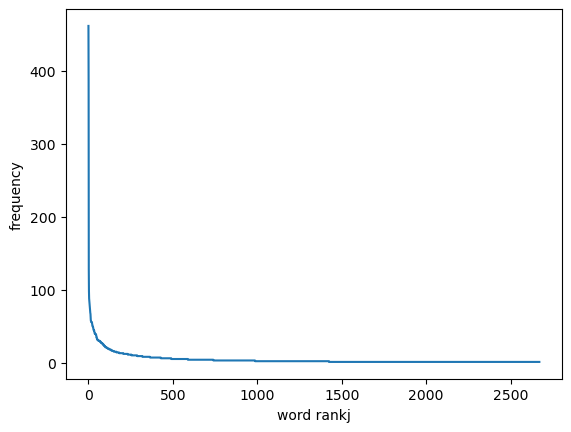

In [21]:
all_frequencies = sorted(list(alice_words_count.values()), reverse = True)
plt.plot(all_frequencies)
plt.xlabel('word rank')
plt.ylabel('frequency')
plt.show()